In [1]:
import re
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_regression
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.naive_bayes import BernoulliNB
from sklearn import tree
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 100)

In [2]:
D = './dataset/'

df_monday = pd.read_csv(D + 'Monday-WorkingHours.pcap_ISCX.csv')
df_tuesday = pd.read_csv(D + 'Tuesday-WorkingHours.pcap_ISCX.csv')
df_wednesday = pd.read_csv(D + 'Wednesday-workingHours.pcap_ISCX.csv')
df_thursday_morning = pd.read_csv(D + 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv')
df_thursday_afternoon = pd.read_csv(D + 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv')
df_friday_morning = pd.read_csv(D + 'Friday-WorkingHours-Morning.pcap_ISCX.csv')
df_friday_afternoon_ddos = pd.read_csv(D + 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
df_friday_afternoon_portscan = pd.read_csv(D + 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv')

In [3]:
data = [df_monday, df_tuesday, df_wednesday, df_thursday_morning, df_thursday_afternoon,
        df_friday_morning, df_friday_afternoon_ddos, df_friday_afternoon_portscan]

# Merge the 8 files into a single DataFrame
df = pd.concat(data, ignore_index=True)

# Column names have inconsistent leading spaces in CICIDS2017: strip them
df.columns = df.columns.str.strip()

# Free memory (the individual DataFrames are no longer needed)
del data, df_monday, df_tuesday, df_wednesday, df_thursday_morning, df_thursday_afternoon
del df_friday_morning, df_friday_afternoon_ddos, df_friday_afternoon_portscan

print(df.shape)

(2830743, 79)


In [4]:
# number of missing data points per column
missing_values_count = df.isnull().sum()
print(missing_values_count[missing_values_count > 0])

# how many total missing values do we have?
total_cells = df.size
total_missing = missing_values_count.sum()

# percent of data that is missing
percent_missing = (total_missing / total_cells) * 100
print(percent_missing)

Flow Bytes/s    1358
dtype: int64
0.0006072565901504135


Data cleaning

In [5]:
# Replace inf values with nan
df_clean = df.replace([np.inf, -np.inf], np.nan)

In [6]:
nan_pct = df_clean.isna().mean() * 100
for column, pct in nan_pct[nan_pct > 0].items():
    print("In column {} the percentage of NaN is {:.4f} %".format(column, pct))

In column Flow Bytes/s the percentage of NaN is 0.1013 %
In column Flow Packets/s the percentage of NaN is 0.1013 %


delete column that contain zero

In [7]:
print("Total columns before deleting {}".format(df_clean.shape[1]))

for column in list(df_clean.columns):
    count = (df_clean[column] == 0).sum()
    percent_of_zeros = (count / df_clean.shape[0]) * 100
    if percent_of_zeros >= 99.0:
        print("Column deleted: {}".format(column))
        df_clean.drop(column, inplace=True, axis=1)

print("Total rows: {}".format(df_clean.shape[0]))
print("Total columns after deleting: {}".format(df_clean.shape[1]))

Total columns before deleting 79
Column deleted: Bwd PSH Flags
Column deleted: Fwd URG Flags
Column deleted: Bwd URG Flags
Column deleted: RST Flag Count
Column deleted: CWE Flag Count
Column deleted: ECE Flag Count
Column deleted: Fwd Avg Bytes/Bulk
Column deleted: Fwd Avg Packets/Bulk
Column deleted: Fwd Avg Bulk Rate
Column deleted: Bwd Avg Bytes/Bulk
Column deleted: Bwd Avg Packets/Bulk
Column deleted: Bwd Avg Bulk Rate
Total rows: 2830743
Total columns after deleting: 67


In [8]:
# Drop rows that still contain NaN (previously inf values)
# NB: we do NOT use -1 as a filler, because -1 is a legitimate value in some
# features (e.g. Init_Win_bytes_forward) and deleting it would remove valid rows.
print("Number of rows before deleting rows {}".format(df_clean.shape[0]))
df_clean = df_clean.dropna().copy()

print("Number of rows after deleting rows {}".format(df_clean.shape[0]))
print("Percentage of deleted rows: {:.2f} %".format(((df.shape[0] - df_clean.shape[0]) / df.shape[0]) * 100))

Number of rows before deleting rows 2830743
Number of rows after deleting rows 2827876
Percentage of deleted rows: 0.10 %


Label encoding

In [9]:
def norm(s):
    # normalise labels: the special character in 'Web Attack � ...' varies with the encoding
    return ' '.join(re.sub(r'[^A-Za-z\- ]', ' ', str(s)).split())

label_names = ['BENIGN', 'FTP-Patator', 'SSH-Patator', 'DoS slowloris', 'DoS Slowhttptest',
               'DoS Hulk', 'DoS GoldenEye', 'Heartbleed', 'Web Attack Brute Force',
               'Web Attack XSS', 'Web Attack Sql Injection', 'Infiltration', 'Bot', 'DDoS', 'PortScan']
label_map = {norm(n): i for i, n in enumerate(label_names)}

df_clean['Label'] = df_clean['Label'].map(lambda s: label_map.get(norm(s)))

unknown = df_clean['Label'].isna().sum()
assert unknown == 0, "{} rows have an unknown label, check df['Label'].unique()".format(unknown)
df_clean['Label'] = df_clean['Label'].astype(int)

print(df_clean['Label'].value_counts().sort_index())

Label
0     2271320
1        7935
2        5897
3        5796
4        5499
5      230124
6       10293
7          11
8        1507
9         652
10         21
11         36
12       1956
13     128025
14     158804
Name: count, dtype: int64


Start of data pre-processing

In [10]:
X = df_clean.drop(columns=['Label'])
y = df_clean['Label']

Mutual information (computed on a sample, the full dataset would take very long)

In [11]:
sample = df_clean.sample(n=min(100_000, len(df_clean)), random_state=0)
X_s = sample.drop(columns=['Label'])
y_s = sample['Label']

mi = mutual_info_classif(X_s, y_s, random_state=0)
coeff_df = pd.DataFrame({'Coefficient': mi}, index=X_s.columns).sort_values('Coefficient', ascending=False)
coeff_df

,Coefficient
Average Packet Size,0.577175
Packet Length Std,0.547014
Packet Length Mean,0.546744
Packet Length Variance,0.546412
Total Length of Bwd Packets,0.499482
Subflow Bwd Bytes,0.499431
Init_Win_bytes_forward,0.490249
Bwd Packet Length Mean,0.489839
Avg Bwd Segment Size,0.488073
Subflow Fwd Bytes,0.485900


In [12]:
# features selected after information gain score evaluated (kept for reference, not used below)
features_selected_col = ["Destination Port", "Average Packet Size", "Packet Length Mean", "Packet Length Std",
                         "Packet Length Variance", "Subflow Bwd Bytes", "Total Length of Bwd Packets",
                         "Bwd Packet Length Mean", "Avg Bwd Segment Size", "Subflow Fwd Bytes",
                         "Total Length of Fwd Packets", "Bwd Packet Length Max", "Max Packet Length",
                         "Fwd Packet Length Max", "Flow IAT Max", "Label"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [14]:
print('Train', X_train.shape, y_train.shape)
print('Test', X_test.shape, y_test.shape)
print('Original', X.shape, df_clean.shape)

Train (1979513, 66) (1979513,)
Test (848363, 66) (848363,)
Original (2827876, 66) (2827876, 67)


In [15]:
# Scaling numerical attributes: fit on train ONLY, then apply the same transform to test
scaler = StandardScaler()

num_cols = X_train.select_dtypes(include='number').columns
sc_train_X = scaler.fit_transform(X_train[num_cols])
sc_test_X = scaler.transform(X_test[num_cols])

sc_traindf_X = pd.DataFrame(sc_train_X, columns=num_cols)
sc_testdf_X = pd.DataFrame(sc_test_X, columns=num_cols)

In [16]:
# Binary target: 1 = BENIGN (class 0), 0 = attack
train_X = sc_traindf_X
train_y = (y_train.values == 0).astype(int)

test_X = sc_testdf_X
test_y = (y_test.values == 0).astype(int)

Random forest

In [17]:
# Feature Selection
rfc = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=0)

# fit random forest classifier on the TRAINING set
rfc.fit(train_X, train_y)

# extract important features
score = np.round(rfc.feature_importances_, 3)
importances = pd.DataFrame({'feature': train_X.columns, 'importance': score})
importances = importances.sort_values('importance', ascending=False).set_index('feature')

,importance
feature,
Bwd Packet Length Std,0.076
Destination Port,0.061
Packet Length Std,0.058
Packet Length Variance,0.057
Average Packet Size,0.054
Bwd Packet Length Mean,0.042
Avg Bwd Segment Size,0.037
Packet Length Mean,0.034
Max Packet Length,0.032


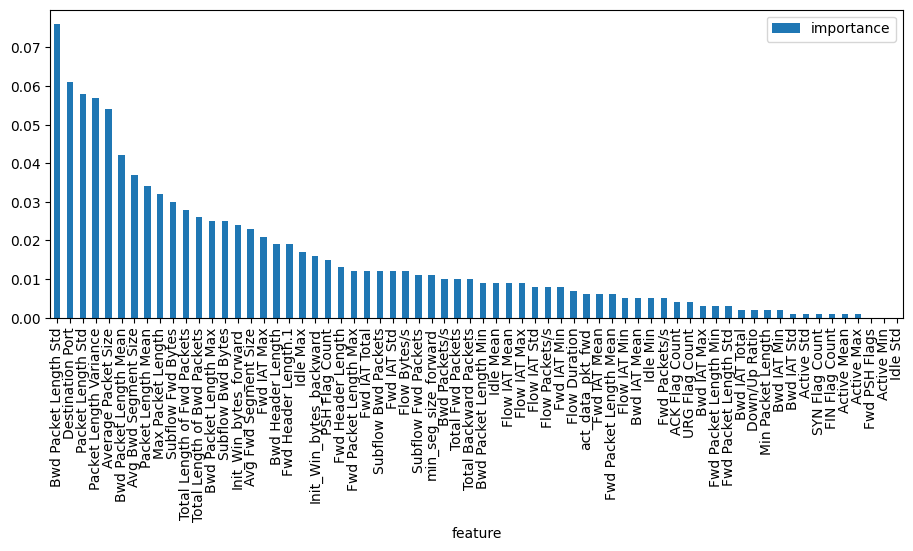

In [18]:
# plot importances
plt.rcParams['figure.figsize'] = (11, 4)
importances.plot.bar();
importances

Dimensionality Reduction

In [19]:
pca = PCA(n_components=15)

pca_features = pca.fit_transform(train_X)

print('Shape before PCA: ', train_X.shape)
print('Shape after PCA: ', pca_features.shape)

pc_cols = ['PC{}'.format(i) for i in range(1, 16)]
train_X = pd.DataFrame(data=pca_features, columns=pc_cols)

Shape before PCA:  (1979513, 66)
Shape after PCA:  (1979513, 15)


In [20]:
# transform only (the PCA was fitted on the training set)
pca_features = pca.transform(test_X)

print('Shape before PCA: ', test_X.shape)
print('Shape after PCA: ', pca_features.shape)

test_X = pd.DataFrame(data=pca_features, columns=pc_cols)

Shape before PCA:  (848363, 66)
Shape after PCA:  (848363, 15)


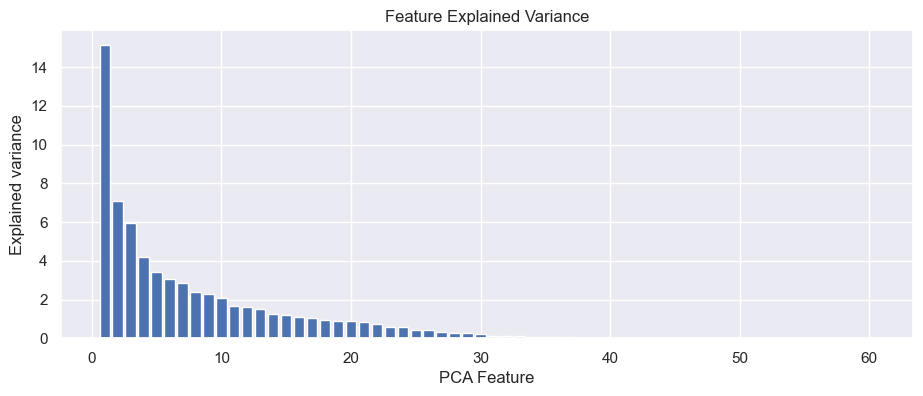

In [21]:
sns.set()

# Explained variance of the first components
pca_full = PCA(n_components=min(60, sc_traindf_X.shape[1]))
pca_full.fit(sc_traindf_X)

plt.bar(range(1, len(pca_full.explained_variance_) + 1), pca_full.explained_variance_)

plt.xlabel('PCA Feature')
plt.ylabel('Explained variance')
plt.title('Feature Explained Variance')
plt.show()

In [22]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

lda = LDA(n_components=1)
train_X = lda.fit_transform(train_X, train_y)
test_X = lda.transform(test_X)

In [23]:
train_X.shape

(1979513, 1)

Random Forest Classifier

In [24]:
classifier = RandomForestClassifier(max_depth=2, random_state=0)

classifier.fit(train_X, train_y)
y_pred = classifier.predict(test_X)

In [25]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

cm = confusion_matrix(test_y, y_pred)
print(cm)
print('Accuracy ' + str(accuracy_score(test_y, y_pred)))

[[ 75907  91474]
 [  5137 675845]]
Accuracy 0.8861206818307729


Knn, Logistic Regression, Bernoulli Naive Bayes and Decision Tree models

In [26]:
# Train KNeighborsClassifier Model
KNN_Classifier = KNeighborsClassifier(n_jobs=-1)
KNN_Classifier.fit(train_X, train_y);

# Train LogisticRegression Model
LGR_Classifier = LogisticRegression(n_jobs=-1, random_state=0)
LGR_Classifier.fit(train_X, train_y);

# Train Bernoulli Naive Bayes Model
BNB_Classifier = BernoulliNB()
BNB_Classifier.fit(train_X, train_y)

# Train Decision Tree Model
DTC_Classifier = tree.DecisionTreeClassifier(criterion='entropy', random_state=0)
DTC_Classifier.fit(train_X, train_y)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [27]:
# Evaluate Models
from sklearn import metrics

accuracy_score_list = []

models = []
models.append(('Naive Baye Classifier', BNB_Classifier))
models.append(('Decision Tree Classifier', DTC_Classifier))
models.append(('KNeighborsClassifier', KNN_Classifier))
models.append(('LogisticRegression', LGR_Classifier))

for name, model in models:
    scores = cross_val_score(model, train_X, train_y, cv=10)
    pred = model.predict(train_X)
    accuracy = metrics.accuracy_score(train_y, pred)
    cm_train = metrics.confusion_matrix(train_y, pred)
    report = metrics.classification_report(train_y, pred)
    print()
    print('============================== {} Model Evaluation =============================='.format(name))
    print()
    print("Cross Validation Mean Score:\n", scores.mean())
    print()
    accuracy_score_list.append(accuracy)
    print("Model Accuracy:\n", accuracy)
    print()
    print("Confusion matrix:\n", cm_train)
    print()
    print("Classification report:\n", report)
    print()

c:\Users\tabib\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tabib\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tabib\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave


============================== Naive Baye Classifier Model Evaluation ==============================

Cross Validation Mean Score:
 0.8033986137022046

Model Accuracy:
 0.8033986136994301

Confusion matrix:
 [[      0  389175]
 [      0 1590338]]

Classification report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00    389175
           1       0.80      1.00      0.89   1590338

    accuracy                           0.80   1979513
   macro avg       0.40      0.50      0.45   1979513
weighted avg       0.65      0.80      0.72   1979513



============================== Decision Tree Classifier Model Evaluation ==============================

Cross Validation Mean Score:
 0.9251679581269447

Model Accuracy:
 0.9986870508049202

Confusion matrix:
 [[ 389074     101]
 [   2498 1587840]]

Classification report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00    389175
           1  

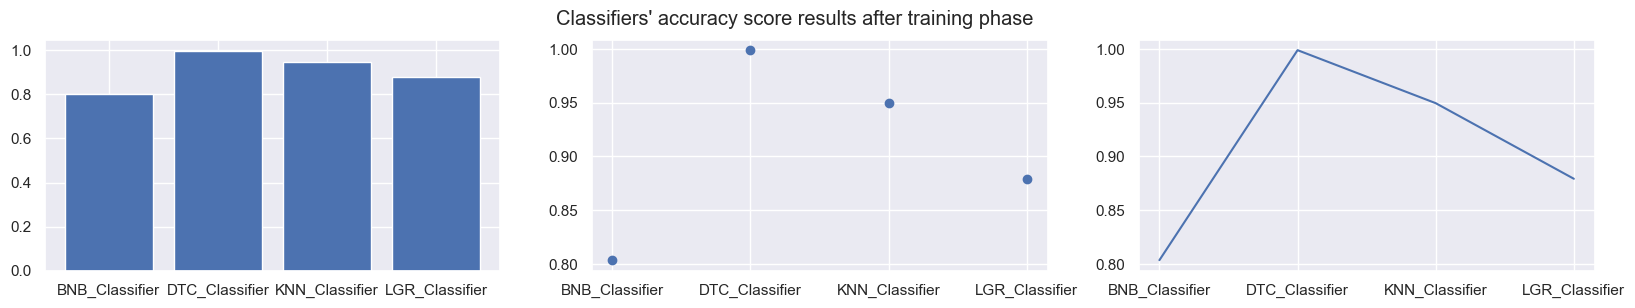

In [28]:
names = ['BNB_Classifier', 'DTC_Classifier', 'KNN_Classifier', 'LGR_Classifier']
values = accuracy_score_list

plt.figure(figsize=(20, 3))

plt.subplot(131)
plt.bar(names, values)
plt.subplot(132)
plt.scatter(names, values)
plt.subplot(133)
plt.plot(names, values)
plt.suptitle("Classifiers' accuracy score results after training phase")
plt.show()

In [29]:
accuracy_score_val_list = []

# Validate Models
for name, model in models:
    pred = model.predict(test_X)
    accuracy = metrics.accuracy_score(test_y, pred)
    cm_test = metrics.confusion_matrix(test_y, pred)
    report = metrics.classification_report(test_y, pred)
    print()
    print('============================== {} Model Test Results =============================='.format(name))
    print()
    print("Model Accuracy:\n", accuracy)
    accuracy_score_val_list.append(accuracy)
    print()
    print("Confusion matrix:\n", cm_test)
    print()
    print("Classification report:\n", report)
    print()

c:\Users\tabib\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tabib\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tabib\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave


============================== Naive Baye Classifier Model Test Results ==============================

Model Accuracy:
 0.8027012021976442

Confusion matrix:
 [[     0 167381]
 [     0 680982]]

Classification report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00    167381
           1       0.80      1.00      0.89    680982

    accuracy                           0.80    848363
   macro avg       0.40      0.50      0.45    848363
weighted avg       0.64      0.80      0.71    848363



============================== Decision Tree Classifier Model Test Results ==============================

Model Accuracy:
 0.9259467940020958

Confusion matrix:
 [[138499  28882]
 [ 33942 647040]]

Classification report:
               precision    recall  f1-score   support

           0       0.80      0.83      0.82    167381
           1       0.96      0.95      0.95    680982

    accuracy                           0.93    848363
   macro 

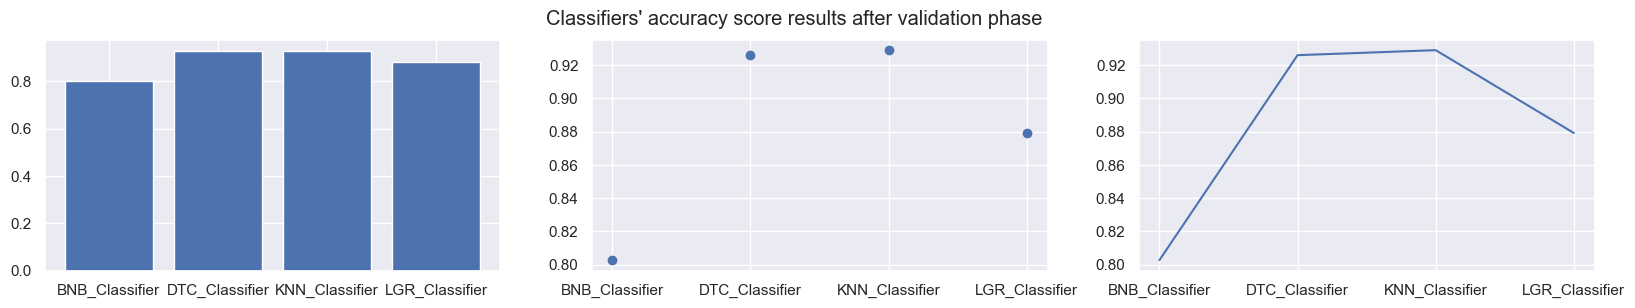

In [30]:
names = ['BNB_Classifier', 'DTC_Classifier', 'KNN_Classifier', 'LGR_Classifier']
values = accuracy_score_val_list

plt.figure(figsize=(20, 3))

plt.subplot(131)
plt.bar(names, values)
plt.subplot(132)
plt.scatter(names, values)
plt.subplot(133)
plt.plot(names, values)
plt.suptitle("Classifiers' accuracy score results after validation phase")
plt.show()